# Example: Robust Regression with Huber & RANSAC

Demonstrates isolating extreme leverage outliers using `HuberRegressorScratch` and `RANSACRegressorScratch` with a visual comparison of fitted slopes.

OLS Slope:    -0.0147 (severely corrupted by outliers)
Huber Slope:  1.9510 (attenuated outlier gradients)
RANSAC Slope: 1.9966 (ground truth ~ 2.0)
RANSAC Inliers detected: 105 / 120


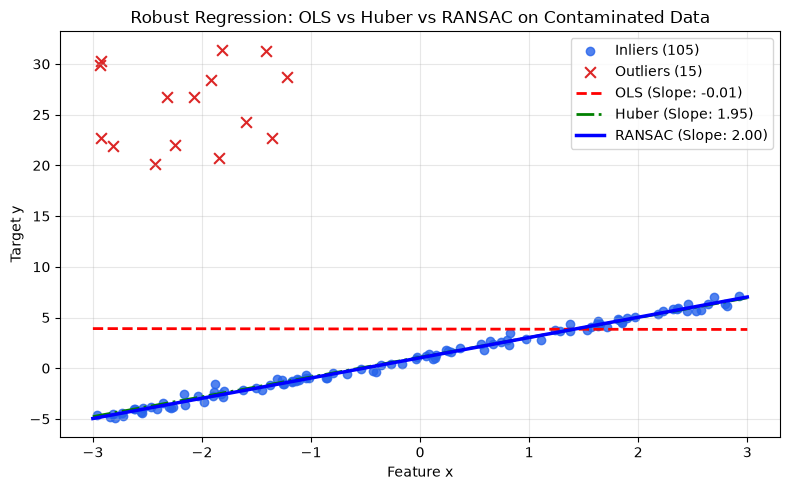

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust import setup: traverse up until 'src' directory is found
root_dir = Path.cwd().resolve()
while not (root_dir / "src").exists() and root_dir != root_dir.parent:
    root_dir = root_dir.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.robust import HuberRegressorScratch, RANSACRegressorScratch
from src.solvers import ClosedFormLinearRegression

np.random.seed(42)
N = 120
x = np.random.uniform(-3, 3, N)
y = 2.0 * x + 1.0 + np.random.normal(0, 0.3, N)

# Inject 15 extreme outliers
x[:15] = np.random.uniform(-3, -1, 15)
y[:15] += 25.0
X = x.reshape(-1, 1)

ols = ClosedFormLinearRegression(method="svd").fit(X, y)
huber = HuberRegressorScratch(epsilon=1.35, lr=0.05, max_iter=300).fit(X, y)
ransac = RANSACRegressorScratch(residual_threshold=1.0, max_trials=100).fit(X, y)

print(f"OLS Slope:    {ols.weights[0]:.4f} (severely corrupted by outliers)")
print(f"Huber Slope:  {huber.weights[0]:.4f} (attenuated outlier gradients)")
print(f"RANSAC Slope: {ransac.estimator_.weights[0]:.4f} (ground truth ~ 2.0)")
print(f"RANSAC Inliers detected: {np.sum(ransac.inlier_mask_)} / {N}")

# Visualize Outlier Rejection
plt.figure(figsize=(8, 5))
inliers = ransac.inlier_mask_
outliers = ~inliers
plt.scatter(x[inliers], y[inliers], color='#2563eb', alpha=0.8, label=f'Inliers ({np.sum(inliers)})')
plt.scatter(x[outliers], y[outliers], color='#dc2626', marker='x', s=60, label=f'Outliers ({np.sum(outliers)})')

grid_x = np.linspace(-3, 3, 200).reshape(-1, 1)
plt.plot(grid_x, ols.predict(grid_x), 'r--', lw=2, label=f'OLS (Slope: {ols.weights[0]:.2f})')
plt.plot(grid_x, huber.predict(grid_x), 'g-.', lw=2, label=f'Huber (Slope: {huber.weights[0]:.2f})')
plt.plot(grid_x, ransac.predict(grid_x), 'b-', lw=2.5, label=f'RANSAC (Slope: {ransac.estimator_.weights[0]:.2f})')

plt.title("Robust Regression: OLS vs Huber vs RANSAC on Contaminated Data")
plt.xlabel("Feature x")
plt.ylabel("Target y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What You Learned
- Why OLS breaks under leverage outliers.
- How Huber loss clips gradients while RANSAC discards contaminated observations completely.